In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
hr = pd.read_csv('HRDataset.csv')


In [4]:
hr

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,01-03-2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,02-01-2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,09-02-2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,02-01-2019,0,11


In [5]:
hr.columns = hr.columns.str.strip()
hr.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='str')

In [6]:
hr.isnull().sum()


Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

In [7]:
hr['DateofTermination'].isnull().value_counts()


DateofTermination
True     207
False    104
Name: count, dtype: int64

In [8]:
hr['EmploymentStatus'] = hr['DateofTermination'].apply(
    lambda x: 'Active' if pd.isnull(x) else 'Terminated'
)

In [9]:
hr['EmploymentStatus']

0          Active
1      Terminated
2      Terminated
3          Active
4      Terminated
          ...    
306        Active
307    Terminated
308        Active
309        Active
310        Active
Name: EmploymentStatus, Length: 311, dtype: str

In [10]:
hr['EmploymentStatus'].value_counts()


EmploymentStatus
Active        207
Terminated    104
Name: count, dtype: int64

In [11]:
hr = hr.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)


In [12]:
hr['DOB'] = hr['DOB'].astype(str).str.replace('-', '/', regex=False)
hr['DOB']

0      07/10/1983
1      05/05/1975
2        09/19/88
3        09/27/88
4      09/08/1989
          ...    
306    05/11/1985
307    05/04/1982
308      08/30/79
309      02/24/79
310      08/17/78
Name: DOB, Length: 311, dtype: str

In [13]:
hr['DOB'] = pd.to_datetime(hr['DOB'].astype(str).str.strip(), errors='coerce', format='mixed')
hr['DOB']

0     1983-07-10
1     1975-05-05
2     1988-09-19
3     1988-09-27
4     1989-09-08
         ...    
306   1985-05-11
307   1982-05-04
308   1979-08-30
309   1979-02-24
310   1978-08-17
Name: DOB, Length: 311, dtype: datetime64[us]

In [14]:
hr['ManagerID'] = hr['ManagerID'].fillna(hr['ManagerID'].mode()[0])


In [15]:
hr['ManagerID']

0      22.0
1       4.0
2      20.0
3      16.0
4      39.0
       ... 
306    20.0
307    12.0
308     2.0
309     4.0
310    14.0
Name: ManagerID, Length: 311, dtype: float64

In [16]:
hr['LastPerformanceReview_Date'] = hr['LastPerformanceReview_Date'].astype(str).str.replace('-', '/', regex=False)


In [17]:
hr['LastPerformanceReview_Date'] = pd.to_datetime(hr['LastPerformanceReview_Date'].astype(str).str.strip(), errors='coerce', format='mixed')

In [18]:
hr['LastPerformanceReview_Date']

0     2019-01-17
1     2016-02-24
2     2012-05-15
3     2019-01-03
4     2016-02-01
         ...    
306   2019-02-28
307   2015-09-02
308   2019-02-21
309   2019-02-01
310   2019-01-30
Name: LastPerformanceReview_Date, Length: 311, dtype: datetime64[us]

In [19]:
col = hr.pop('EmploymentStatus')


In [20]:
hr.insert(hr.columns.get_loc('DateofHire') + 1,
          'EmploymentStatus',
          col)

In [21]:
hr['DateofHire'] = hr['DateofHire'].astype(str).str.replace('-', '/', regex=False)


In [22]:
hr['DateofHire'] = pd.to_datetime(hr['DateofHire'].astype(str).str.strip(), errors='coerce', format='mixed')
hr['DateofHire']


0     2011-07-05
1     2015-03-30
2     2011-07-05
3     2008-01-07
4     2011-07-11
         ...    
306   2014-07-07
307   2008-09-02
308   2010-04-10
309   2015-03-30
310   2014-09-29
Name: DateofHire, Length: 311, dtype: datetime64[us]

In [23]:
hr = hr.drop([ 'Employee_Name', 'MarriedID', 'MaritalStatusID', 'GenderID',
    'EmpStatusID', 'DeptID', 'PerfScoreID', 'PositionID', 'ManagerID',
    'Zip', 'DOB', 'CitizenDesc', 'HispanicLatino', 'FromDiversityJobFairID',
    'LastPerformanceReview_Date'
], axis=1)

In [24]:
hr.columns.tolist()


['EmpID',
 'Salary',
 'Termd',
 'Position',
 'State',
 'Sex',
 'MaritalDesc',
 'RaceDesc',
 'DateofHire',
 'EmploymentStatus',
 'DateofTermination',
 'TermReason',
 'Department',
 'ManagerName',
 'RecruitmentSource',
 'PerformanceScore',
 'EngagementSurvey',
 'EmpSatisfaction',
 'SpecialProjectsCount',
 'DaysLateLast30',
 'Absences']

In [25]:
hr.to_csv('Data_Cleaned/hr_database_cleaned.csv', index=False)

In [26]:
hr_new = pd.read_csv('Data_Cleaned/hr_database_cleaned.csv')


In [27]:
hr_new

,EmpID,Salary,Termd,Position,State,Sex,MaritalDesc,RaceDesc,DateofHire,EmploymentStatus,...,TermReason,Department,ManagerName,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
0,10026,62506,0,Production Technician I,MA,M,Single,White,2011-07-05,Active,...,N/A-StillEmployed,Production,Michael Albert,LinkedIn,Exceeds,4.60,5,0,0,1
1,10084,104437,1,Sr. DBA,MA,M,Married,White,2015-03-30,Terminated,...,career change,IT/IS,Simon Roup,Indeed,Fully Meets,4.96,3,6,0,17
2,10196,64955,1,Production Technician II,MA,F,Married,White,2011-07-05,Terminated,...,hours,Production,Kissy Sullivan,LinkedIn,Fully Meets,3.02,3,0,0,3
3,10088,64991,0,Production Technician I,MA,F,Married,White,2008-01-07,Active,...,N/A-StillEmployed,Production,Elijiah Gray,Indeed,Fully Meets,4.84,5,0,0,15
4,10069,50825,1,Production Technician I,MA,F,Divorced,White,2011-07-11,Terminated,...,return to school,Production,Webster Butler,Google Search,Fully Meets,5.00,4,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,10135,65893,0,Production Technician II,MA,M,Single,White,2014-07-07,Active,...,N/A-StillEmployed,Production,Kissy Sullivan,LinkedIn,Fully Meets,4.07,4,0,0,13
307,10301,48513,1,Production Technician I,MA,F,Single,Asian,2008-09-02,Terminated,...,Another position,Production,Brannon Miller,Google Search,PIP,3.20,2,0,5,4
308,10010,220450,0,CIO,MA,F,Single,White,2010-04-10,Active,...,N/A-StillEmployed,IT/IS,Janet King,Employee Referral,Exceeds,4.60,5,6,0,16
309,10043,89292,0,Data Analyst,MA,F,Single,White,2015-03-30,Active,...,N/A-StillEmployed,IT/IS,Simon Roup,Employee Referral,Fully Meets,5.00,3,5,0,11


In [28]:
# Q1 — Headcount by Department
headcount = hr_new['Department'].value_counts()
print(headcount)


Department
Production              209
IT/IS                    50
Sales                    31
Software Engineering     11
Admin Offices             9
Executive Office          1
Name: count, dtype: int64


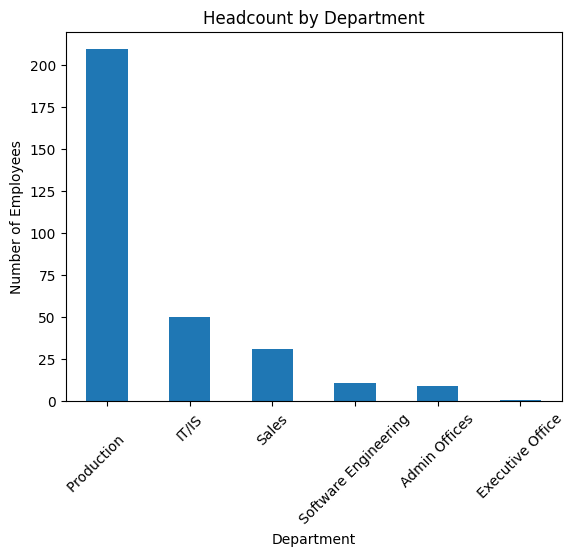

In [29]:
# Diagram
headcount.plot(kind='bar')
plt.title("Headcount by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()


In [30]:
# Q2 — Average salary by Department
Avg_salary = hr_new.groupby('Department')['Salary'].mean().round(2)
print(Avg_salary.sort_values(ascending=False))

Department
Executive Office        250000.00
IT/IS                    97064.64
Software Engineering     94989.45
Admin Offices            71791.89
Sales                    69061.26
Production               59953.55
Name: Salary, dtype: float64


In [31]:
# Q3 — Gender pay gap by Department
Gender_salary = hr_new.groupby(['Department','Sex'])['Salary'].mean().round(2)
print(Gender_salary)

Department            Sex
Admin Offices         F       70926.33
                      M       73523.00
Executive Office      F      250000.00
IT/IS                 F       94593.00
                      M       99006.64
Production            F       59620.42
                      M       60459.25
Sales                 F       72016.67
                      M       66290.56
Software Engineering  F       96906.17
                      M       92689.40
Name: Salary, dtype: float64


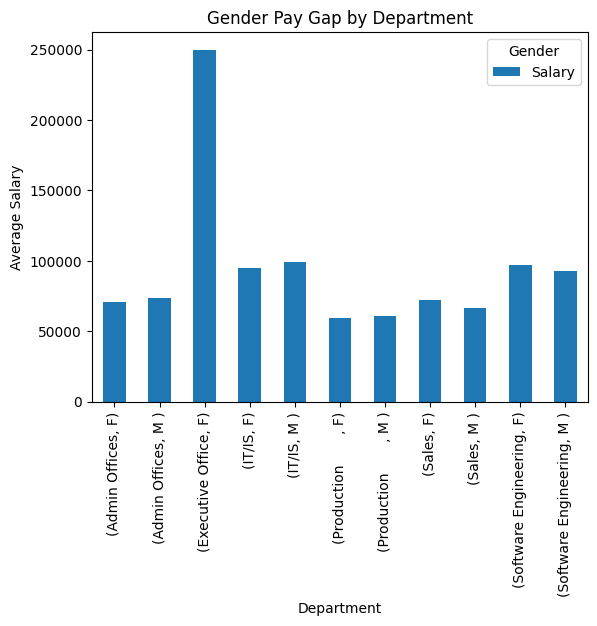

In [32]:
# Diagram
Gender_salary.plot(kind='bar')
plt.title("Gender Pay Gap by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=90)
plt.legend(title="Gender")
plt.show()


In [33]:
hiring_trend = hr['DateofHire'].dt.year.value_counts().sort_index()
print(hiring_trend)

DateofHire
2006     1
2007     2
2008     3
2009     7
2010     9
2011    83
2012    45
2013    44
2014    60
2015    36
2016    14
2017     6
2018     1
Name: count, dtype: int64


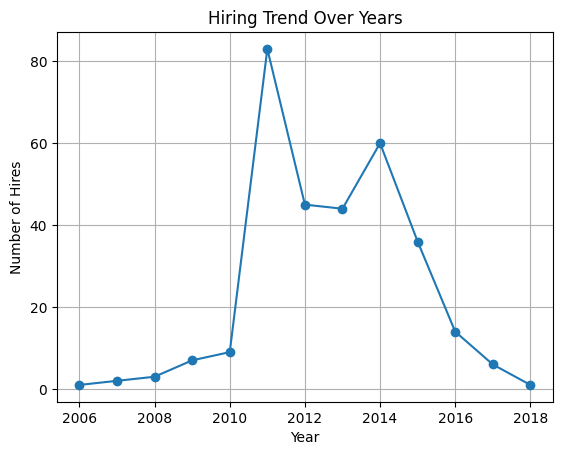

In [34]:
# Diagram
hiring_trend.plot(kind='line', marker='o')
plt.title("Hiring Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Hires")
plt.grid()
plt.show()
